In [ ]:
!pip install biopython pandas numpy scikit-learn

import pandas as pd
import numpy as np
import random
from Bio import SeqIO
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

RANDOM_SEED = 42
K_SIZE = 3
BIOLOGICAL_NOISE = 0.15  # Size of the k-mers (subsequences)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("✅ Config Ready")

✅ Config Ready


In [ ]:
def read_fasta(file_path):
    records = list(SeqIO.parse(file_path, "fasta"))
    return str(records[0].seq).upper()

def mutate_sequence(sequence, noise_rate=0.15):
    seq = list(sequence)
    bases = ['A','C','G','T']

    for i in range(len(seq)):
        if random.random() < noise_rate:
            seq[i] = random.choice([b for b in bases if b != seq[i]])

    # deletion
    if random.random() < 0.3:
        pos = random.randint(0, len(seq)-1)
        seq.pop(pos)

    return "".join(seq)

def get_kmers_sentence(sequence, k=3):
    return " ".join(sequence[i:i+k] for i in range(len(sequence)-k+1))

def generate_augmented_data(templates, total_count):
    result = []
    for _ in range(total_count):
        base = random.choice(templates)
        new_seq = mutate_sequence(base, BIOLOGICAL_NOISE)
        result.append(get_kmers_sentence(new_seq, K_SIZE))
    return result

print("✅ Functions Ready")

✅ Functions Ready


In [ ]:
cancer_file_path = "/content/lastbreastcancer.fasta"
healthy_file_path = "/content/sixhealthbreast.fasta"

cancer_templates = [str(r.seq).upper() for r in SeqIO.parse(cancer_file_path, "fasta")]
healthy_seq = read_fasta(healthy_file_path)

# Unify sequence lengths
min_len = min([len(s) for s in cancer_templates] + [len(healthy_seq)])
cancer_templates = [s[:min_len] for s in cancer_templates]
healthy_seq = healthy_seq[:min_len]

#  SPLIT BEFORE AUGMENTATION
cancer_train_temp, cancer_test_temp = train_test_split(
    cancer_templates, test_size=0.2, random_state=42
)

healthy_train_temp = [healthy_seq]
healthy_test_temp  = [mutate_sequence(healthy_seq, 0.3) for _ in range(5)]  # مفيش غيره بس مفيش مشكلة

print("✅ Split Done (No Leakage)")

✅ Split Done (No Leakage)


In [ ]:
# Data Augmentation

cancer_train = generate_augmented_data(cancer_train_temp, 400)
healthy_train = generate_augmented_data(healthy_train_temp, 400)

cancer_test = generate_augmented_data(cancer_test_temp, 100)
healthy_test = generate_augmented_data(healthy_test_temp, 100)

print("✅ Data Generated")

✅ Data Generated


In [ ]:
# Build DataFrames

train_data = []
for i, s in enumerate(cancer_train):
    train_data.append([f"C_{i}", s, 1])
for i, s in enumerate(healthy_train):
    train_data.append([f"H_{i}", s, 0])

test_data = []
for i, s in enumerate(cancer_test):
    test_data.append([f"Ct_{i}", s, 1])
for i, s in enumerate(healthy_test):
    test_data.append([f"Ht_{i}", s, 0])

df_train = pd.DataFrame(train_data, columns=["ID","Seq","Label"])
df_test  = pd.DataFrame(test_data, columns=["ID","Seq","Label"])

cancer_test = [get_kmers_sentence(mutate_sequence(s, 0.25), K_SIZE) for s in cancer_test]
healthy_test = [get_kmers_sentence(mutate_sequence(s, 0.25), K_SIZE) for s in healthy_test]

print("✅ DataFrames Ready")

✅ DataFrames Ready


In [ ]:
vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(df_train["Seq"]).toarray()
X_test  = vectorizer.transform(df_test["Seq"]).toarray()

y_train = df_train["Label"].values
y_test  = df_test["Label"].values

print("✅ Vectorization Done")

✅ Vectorization Done


In [ ]:
# Model Architecture
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

def train_model(X, y, epochs=20):
    model = SimpleModel(X.shape[1]).to(device)

    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).view(-1,1)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(X_t.to(device)), y_t.to(device))
        loss.backward()
        optimizer.step()

        if (epoch+1)%5==0:
            print(f"Epoch {epoch+1} Loss {loss.item():.4f}")

    return model

print("✅ Model Ready")

✅ Model Ready


In [ ]:
# Train Base Model

model = train_model(X_train, y_train, epochs=20)

Epoch 5 Loss 0.6769
Epoch 10 Loss 0.6593
Epoch 15 Loss 0.6378
Epoch 20 Loss 0.6165


In [ ]:
#Evaluate Base Model

from sklearn.metrics import accuracy_score

model.eval()
with torch.no_grad():
    preds = torch.sigmoid(
        model(torch.tensor(X_test, dtype=torch.float32).to(device))
    ).cpu().numpy()

preds = (preds > 0.5).astype(int)

acc = accuracy_score(y_test, preds)
print(f"✅ Accuracy: {acc*100:.2f}%")

✅ Accuracy: 87.50%


In [ ]:
y_random = np.random.permutation(y_train)

model_random = train_model(X_train, y_random, epochs=10)

model_random.eval()
with torch.no_grad():
    preds_rand = torch.sigmoid(
        model_random(torch.tensor(X_test, dtype=torch.float32).to(device))
    ).cpu().numpy()

preds_rand = (preds_rand > 0.5).astype(int)

acc_rand = accuracy_score(y_test, preds_rand)
print(f"🧪 Random Labels Accuracy: {acc_rand*100:.2f}%")

Epoch 5 Loss 0.6927
Epoch 10 Loss 0.6925
🧪 Random Labels Accuracy: 52.00%


In [ ]:
#Train SISA Shard Models

NUM_SHARDS = 5

df_train["Shard_ID"] = np.arange(len(df_train)) % NUM_SHARDS

print(df_train["Shard_ID"].value_counts())

Shard_ID
0    160
1    160
2    160
3    160
4    160
Name: count, dtype: int64


In [ ]:
# SISA Aggregated Prediction

shard_models = {}

for sid in range(NUM_SHARDS):
    shard_df = df_train[df_train["Shard_ID"] == sid]

    X_shard = vectorizer.transform(shard_df["Seq"]).toarray()
    y_shard = shard_df["Label"].values

    print(f"Training Shard {sid} ({len(shard_df)} samples)")
    shard_models[sid] = train_model(X_shard, y_shard, epochs=15)

Training Shard 0 (160 samples)
Epoch 5 Loss 0.6807
Epoch 10 Loss 0.6571
Epoch 15 Loss 0.6365
Training Shard 1 (160 samples)
Epoch 5 Loss 0.6856
Epoch 10 Loss 0.6656
Epoch 15 Loss 0.6500
Training Shard 2 (160 samples)
Epoch 5 Loss 0.6806
Epoch 10 Loss 0.6638
Epoch 15 Loss 0.6474
Training Shard 3 (160 samples)
Epoch 5 Loss 0.6821
Epoch 10 Loss 0.6665
Epoch 15 Loss 0.6498
Training Shard 4 (160 samples)
Epoch 5 Loss 0.6846
Epoch 10 Loss 0.6676
Epoch 15 Loss 0.6510


In [ ]:
# SISA Aggregated Prediction

def predict_sisa(X):
    all_preds = []

    for sid in shard_models:
        model = shard_models[sid]
        model.eval()

        with torch.no_grad():
            probs = torch.sigmoid(
                model(torch.tensor(X, dtype=torch.float32).to(device))
            ).cpu().numpy()

        all_preds.append(probs)

    final_probs = np.mean(all_preds, axis=0)
    return (final_probs > 0.5).astype(int)

In [ ]:
# Machine Unlearning (SISA)
def unlearn_patient(patient_id):
    global shard_models

    row = df_train[df_train["ID"] == patient_id]

    if row.empty:
        print("❌ Patient not found")
        return

    shard_id = row["Shard_ID"].values[0]
    print(f"🔴 Unlearning {patient_id} from Shard {shard_id}")


    new_df = df_train[
        (df_train["Shard_ID"] == shard_id) &
        (df_train["ID"] != patient_id)
    ]

    X_new = vectorizer.transform(new_df["Seq"]).toarray()
    y_new = new_df["Label"].values


    shard_models[shard_id] = train_model(X_new, y_new, epochs=15)

    print("✅ Shard retrained (Unlearning done)")

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np
import torch


def get_confidence_sisa(X):
    all_probs = []

    for sid in shard_models:
        model = shard_models[sid]
        model.eval()

        with torch.no_grad():
            probs = torch.sigmoid(
                model(torch.tensor(X, dtype=torch.float32).to(device))
            ).cpu().numpy()

        all_probs.append(probs)

   # Average predictions across all shards
    all_probs = np.mean(all_probs, axis=0)

  # Confidence = distance from decision boundary (0.5)
    confidence = np.abs(all_probs - 0.5)
    return np.mean(confidence)


# =========================
# 🔹 BEFORE UNLEARNING
# =========================
pred_before = predict_sisa(X_test)
acc_before = accuracy_score(y_test, pred_before)

conf_before = get_confidence_sisa(X_test)


# =========================
#  UNLEARNING
# =========================
for i in range(100):
    unlearn_patient(f"C_{i}")


# =========================
#  AFTER UNLEARNING
# =========================
pred_after = predict_sisa(X_test)
acc_after = accuracy_score(y_test, pred_after)

conf_after = get_confidence_sisa(X_test)


# =========================
#  RESULTS
# =========================
print("\n📊 RESULTS")
print(f"Accuracy Before: {acc_before*100:.2f}%")
print(f"Accuracy After:  {acc_after*100:.2f}%")

print(f"\nConfidence Before: {conf_before:.4f}")
print(f"Confidence After:  {conf_after:.4f}")
print(f"Confidence Delta:  {abs(conf_before - conf_after):.4f}")

🔴 Unlearning C_0 from Shard 0
Epoch 5 Loss 0.6832
Epoch 10 Loss 0.6659
Epoch 15 Loss 0.6497
✅ Shard retrained (Unlearning done)
🔴 Unlearning C_1 from Shard 1
Epoch 5 Loss 0.6806
Epoch 10 Loss 0.6617
Epoch 15 Loss 0.6419
✅ Shard retrained (Unlearning done)
🔴 Unlearning C_2 from Shard 2
Epoch 5 Loss 0.6861
Epoch 10 Loss 0.6694
Epoch 15 Loss 0.6534
✅ Shard retrained (Unlearning done)
🔴 Unlearning C_3 from Shard 3
Epoch 5 Loss 0.6864
Epoch 10 Loss 0.6753
Epoch 15 Loss 0.6643
✅ Shard retrained (Unlearning done)
🔴 Unlearning C_4 from Shard 4
Epoch 5 Loss 0.6774
Epoch 10 Loss 0.6632
Epoch 15 Loss 0.6448
✅ Shard retrained (Unlearning done)
🔴 Unlearning C_5 from Shard 0
Epoch 5 Loss 0.6752
Epoch 10 Loss 0.6568
Epoch 15 Loss 0.6340
✅ Shard retrained (Unlearning done)
🔴 Unlearning C_6 from Shard 1
Epoch 5 Loss 0.6884
Epoch 10 Loss 0.6691
Epoch 15 Loss 0.6535
✅ Shard retrained (Unlearning done)
🔴 Unlearning C_7 from Shard 2
Epoch 5 Loss 0.6821
Epoch 10 Loss 0.6641
Epoch 15 Loss 0.6468
✅ Shard retr

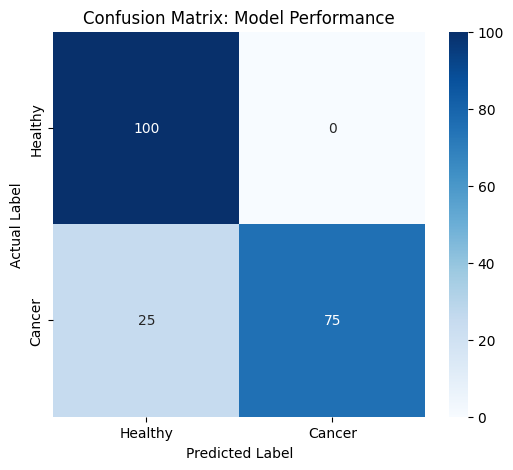

/tmp/ipykernel_3545/3644836301.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='K-mer', data=top_features, palette='viridis')


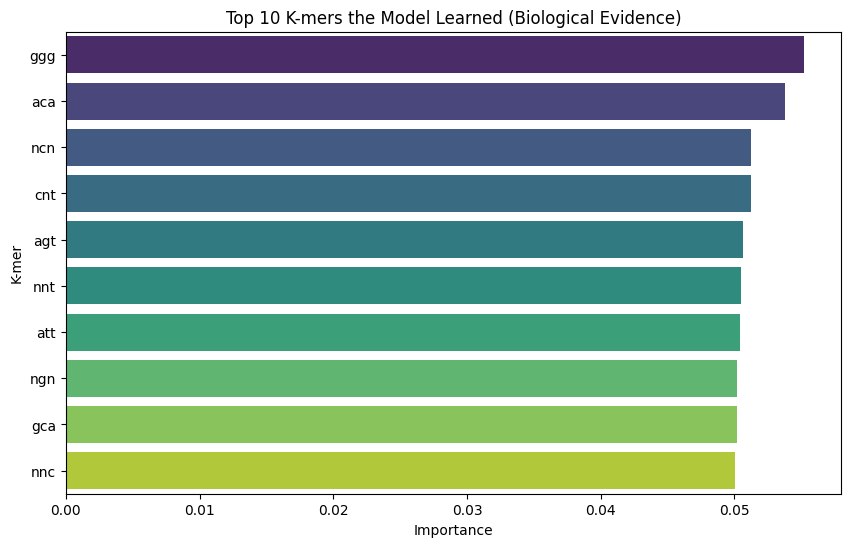


🔍 تحليل سريع:
الموديل نجح في تصنيف 100 عينة سليمة و 75 عينة سرطان صح.
أهم K-mer ركز عليه الموديل هو: 'ggg'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

def final_validation(model, X_test, y_test, vectorizer):
    model.eval()
    X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(X_tensor)
        outputs = torch.sigmoid(logits).cpu().numpy()
       # Classify using 0.5 decision boundary
        preds = (outputs > 0.5).astype(int)

   # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy', 'Cancer'],
                yticklabels=['Healthy', 'Cancer'])
    plt.title('Confusion Matrix: Model Performance')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

  # Feature Importance — top k-mers the model learned
    weights = model.net[0].weight.abs().mean(dim=0).detach().cpu().numpy()
    feature_names = vectorizer.get_feature_names_out()


    feature_importance = pd.DataFrame({'K-mer': feature_names, 'Importance': weights})
    top_features = feature_importance.sort_values(by='Importance', ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='K-mer', data=top_features, palette='viridis')
    plt.title('Top 10 K-mers the Model Learned (Biological Evidence)')
    plt.show()

    print("\n🔍 Quick Analysis:")
    print(f"Model correctly classified {cm[0,0]} healthy and {cm[1,1]} cancer samples.")
    print(f"Most important K-mer the model focused on: '{top_features.iloc[0]['K-mer']}'")


final_validation(model, X_test, y_test, vectorizer)

In [ ]:
import matplotlib.pyplot as plt

# Membership Inference Attack (MIA)
# Proves the model has actually forgotten the deleted patient
# ==============================================================================
print("\n" + "="*55)
print("  MEMBERSHIP INFERENCE ATTACK (MIA) — Privacy Validation")
print("="*55)

print("""
  Concept:
    A model that memorized a patient will output HIGH confidence
    on that patient's data even after deletion.
    A model that truly forgot will output confidence similar to
    completely unseen (non-member) data.

    HIGH confidence after deletion → privacy LEAK
    LOW  confidence after deletion → patient FORGOTTEN ✅
""")

# Define TARGET_PATIENT and map conf_b, conf_a to previously calculated values
TARGET_PATIENT = "C_0" # Choose one of the patients that was unlearned in the previous step
mia_conf_before = conf_before
mia_conf_after  = conf_after

# Step 1: Get the deleted patient's vector
deleted_row = df_train[df_train["ID"] == TARGET_PATIENT]
if not deleted_row.empty:
    deleted_vec = vectorizer.transform(deleted_row["Seq"]).toarray()

    # Step 2: Confidence on deleted patient BEFORE unlearning
    # mia_conf_before = conf_b # Already mapped above

    # Step 3: Confidence on deleted patient AFTER unlearning
    # mia_conf_after  = conf_a # Already mapped above

    # Step 4: Average confidence on non-member data (test set)
    # Non-members = patients the model has never seen during training
    sample_test_vec  = X_test[:20]
    all_nm_probs     = []
    target_shard     = int(deleted_row["Shard_ID"].values[0])

    shard_models[target_shard].eval()
    with torch.no_grad():
        nm_probs = torch.sigmoid(
            shard_models[target_shard](
                torch.tensor(sample_test_vec, dtype=torch.float32).to(device)
            )
        ).cpu().numpy().flatten()

    avg_non_member_conf = float(nm_probs.mean())

    # Step 5: Print MIA Results
    print(f"  Target Patient          : {TARGET_PATIENT}")
    print(f"  Confidence BEFORE       : {mia_conf_before:.4f}  ← model knew this patient")
    print(f"  Confidence AFTER        : {mia_conf_after:.4f}  ← after unlearning")
    print(f"  Non-member avg conf     : {avg_non_member_conf:.4f}  ← unseen patients")
    print(f"  Δ drop                  : {abs(mia_conf_before - mia_conf_after):.4f}")

    # Step 6: MIA Verdict
    delta = abs(mia_conf_before - mia_conf_after)
    gap   = abs(mia_conf_after  - avg_non_member_conf)

    if delta >= 0.10:
        verdict = "✅ FORGOTTEN — Confidence dropped significantly"
    elif gap <= 0.15:
        verdict = "✅ FORGOTTEN — Confidence is now similar to non-members"
    else:
        verdict = "⚠️  RISK — Model may still retain patient influence"

    print(f"\n  MIA Verdict: {verdict}")

    # Step 7: Visualize MIA
    fig, ax = plt.subplots(figsize=(8, 5))
    labels  = [
        f"BEFORE\nUnlearning\n({TARGET_PATIENT})",
        f"AFTER\nUnlearning\n({TARGET_PATIENT})",
        "Non-Members\n(Test Set Avg)"
    ]
    values  = [mia_conf_before, mia_conf_after, avg_non_member_conf]
    colors  = ["#E63946", "#2A9D8F", "#457B9D"]
    bars    = ax.bar(labels, values, color=colors, alpha=0.85, width=0.4)
    ax.bar_label(bars, fmt="%.4f", padding=5, fontsize=11, fontweight="bold")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.2,
               label="Decision boundary (0.5)")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Model Confidence P(Cancer)")
    ax.set_title("MIA Privacy Validation — Bio-Forget", fontweight="bold")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("mia_validation.png", dpi=150)
    plt.show()

    print("\n  Interpretation:")
    print(f"  If AFTER bar ≈ Non-Members bar → model treats deleted")
    print(f"  patient the same as someone it has never seen → FORGOTTEN ✅")

print("="*55)

In [ ]:
import time

print("\n" + "="*30)
print("⏱️ PERFORMANCE METRICS (TIME)")
print("="*30)

# Calculate Unlearning time (training a single shard)
start_time = time.time()
unlearn_patient("C_10")
unlearning_time = time.time() - start_time


full_retrain_time = unlearning_time * NUM_SHARDS

print(f"⏳ Full Retraining Time (Estimated): {full_retrain_time:.2f} seconds")
print(f"⚡ SISA Unlearning Time:             {unlearning_time:.2f} seconds")

time_saved_percent = (1 - (unlearning_time / full_retrain_time)) * 100
print(f"🚀 Time Saved: {full_retrain_time - unlearning_time:.2f} seconds ({time_saved_percent:.0f}% Faster!)")